<a href="https://www.kaggle.com/code/bryanchau/file04?scriptVersionId=301237226" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Phase 6 — Weight-First Nutrition Prediction

**Following the professor's specification**: predict dish **weight in grams** first from  
geometric features (YOLO mask area + MiDaS depth), then convert to calories/fat/protein/carbs  
using **calorie-density constants** derived from the Nutrition5K dataset.

### Why weight-first is better
- Direct calorie regression (Phase 4) ignores food type — a flat sashimi slice and a flat pizza  
  have similar geometry but wildly different calorie density.
- Predicting **weight** is purely a physical/geometric task — depth + area → volume → mass.  
  The model is not asked to know nutritional chemistry, only physics.
- Calorie/macro densities (kcal per gram) are **fixed dataset constants** derived from the  
  mean across all Nutrition5K dishes.

### Pipeline
```
Input image
    ↓
YOLOv8-seg ──→ food mask
MiDaS ────────→ depth map
    ↓
9 geometric features
    ↓
WeightMLP (9→128→64→32→1)
    ↓
predicted weight ŵ (grams)
    ↓
× dataset constants
    ↓
calories = ŵ × cal_per_g
fat      = ŵ × fat_per_g
protein  = ŵ × protein_per_g
carbs    = ŵ × carbs_per_g
```

### Files produced
| File | Description |
|---|---|
| `best_weight_mlp.pt` | WeightMLP checkpoint |
| `nutrition_constants.json` | Dataset-derived density constants |
| `weight_feat_stats.npz` | Feature normalisation stats |

Place all three in `models/` together with the Phase 4 + 5 artefacts.

## Cell 1 — Install / Import Required Libraries

In [4]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

try:
    from ultralytics import YOLO
except ImportError:
    pip('ultralytics')
    from ultralytics import YOLO

import os, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import cv2
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset

import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {device}')

PyTorch 2.9.0+cu126  |  device: cuda


## Cell 2 — Configuration & Paths

In [ ]:

# ── Output paths ──────────────────────────────────────────────────────────────
OUTPUT_DIR       = '/kaggle/working'
WEIGHT_MLF_CKPT  = os.path.join(OUTPUT_DIR, 'best_weight_mlp.pt')
NUTR_CONST_PATH  = os.path.join(OUTPUT_DIR, 'nutrition_constants.json')
WEIGHT_STATS_PATH= os.path.join(OUTPUT_DIR, 'weight_feat_stats.npz')
CACHE_PATH       = os.path.join(OUTPUT_DIR, 'weight_features_cache.npz')

# ── Training config ───────────────────────────────────────────────────────────
CFG = dict(
    img_size       = 224,
    feat_size      = 9,
    batch_size     = 64,
    num_epochs     = 60,
    lr             = 1e-3,
    weight_decay   = 1e-4,
    dropout        = 0.2,
    patience       = 8,        # ReduceLROnPlateau patience
    mc_samples     = 30,       # MC Dropout inference samples
    # Fix 3 — log-weight target
    # Training on log(w + LOG_OFFSET) squashes the heavy tail of the weight
    # distribution (35–1200 g) so large dishes don't dominate Huber loss.
    # At inference: w_grams = exp(model_output) - LOG_OFFSET
    use_log_target = True,
    log_offset     = 1.0,      # log(w + 1) — avoids log(0) for w=0 edge case
)

print('Config:')
for k, v in CFG.items():
    print(f'  {k:20s}: {v}')


Config:
  img_size            : 224
  feat_size           : 9
  batch_size          : 64
  num_epochs          : 60
  lr                  : 0.001
  weight_decay        : 0.0001
  dropout             : 0.2
  patience            : 8
  mc_samples          : 30


## Cell 3 — Load Nutrition5K & Compute Dataset Constants

The **calorie-density constants** are the heart of the weight-first approach.  
We compute the mean ratio `macro / weight_g` across every valid dish in Nutrition5K.  
These become the fixed multipliers we use at inference time:

$$\hat{\text{calories}} = \hat{w}_g \times c_{\text{cal/g}}$$
$$\hat{\text{fat}} = \hat{w}_g \times c_{\text{fat/g}}$$

In [6]:
# ── Step 1: Auto-detect Nutrition5K dataset paths ─────────────────────────────
KAGGLE_ROOT = '/kaggle/input'
LOCAL_DATA  = '../data'

nutrition_csv = img_dir = None
search_root = KAGGLE_ROOT if os.path.isdir(KAGGLE_ROOT) else LOCAL_DATA

for root, dirs, files in os.walk(search_root):
    for f in files:
        if f == 'dish_nutrition_values.csv':
            nutrition_csv = os.path.join(root, f); break
    if nutrition_csv: break

for root, dirs, files in os.walk(search_root):
    if len([d for d in dirs if d.startswith('dish_')]) > 10:
        img_dir = root; break

assert nutrition_csv and os.path.isfile(nutrition_csv), \
    f'dish_nutrition_values.csv not found under {search_root}'
assert img_dir and os.path.isdir(img_dir), \
    f'Dish image directory not found under {search_root}'

print(f'CSV      : {nutrition_csv}')
print(f'Image dir: {img_dir}')

# ── Step 2: Load CSV & discover column names ──────────────────────────────────
df = pd.read_csv(nutrition_csv)
dish_id_col = df.columns[0]

print(f'Columns  : {list(df.columns)}')

def find_col(df, kws):
    for kw in kws:
        m = next((c for c in df.columns if kw in c.lower()), None)
        if m: return m
    return None

# Nutrition5K uses 'mass' for dish weight (some versions use 'weight' or 'total_weight')
WEIGHT_COL   = find_col(df, ['weight', 'mass'])
CALORIES_COL = find_col(df, ['calor'])
FAT_COL      = find_col(df, ['fat'])
PROTEIN_COL  = find_col(df, ['protein'])
CARBS_COL    = find_col(df, ['carb'])

TARGET_COLS  = [c for c in [CALORIES_COL, FAT_COL, PROTEIN_COL, CARBS_COL] if c]

assert WEIGHT_COL, (
    f'Weight/mass column not found. Columns available: {list(df.columns)}\n'
    'Expected a column named mass, weight, total_weight, or weight_g.'
)

print(f'Weight column : {WEIGHT_COL}')
print(f'Nutrition cols: {TARGET_COLS}')
print(f'CSV shape     : {df.shape}')

# ── Step 3: Filter to dishes that have image folders ─────────────────────────
available = set(os.listdir(img_dir))

def has_images(did):
    p = os.path.join(img_dir, did)
    return os.path.isdir(p) and any(
        f.lower().endswith(('.jpg', '.png'))
        for f in os.listdir(p)
    )

df_valid = df[df[dish_id_col].isin(available)].reset_index(drop=True)
df_valid = df_valid[df_valid[dish_id_col].apply(has_images)].reset_index(drop=True)

# Drop rows where weight is missing or zero (can't compute constants)
df_valid = df_valid[df_valid[WEIGHT_COL].notna() & (df_valid[WEIGHT_COL] > 0)]
df_valid = df_valid.reset_index(drop=True)
print(f'\nValid dishes with weight data: {len(df_valid)}')

# ── Step 4: Compute dataset constants ─────────────────────────────────────────
# c_macro/g = mean(macro_value / weight_g) over all valid dishes
# These are the fixed multipliers used at inference: nutrition = weight_pred * constant

weights_arr  = df_valid[WEIGHT_COL].values.astype(np.float64)

constants = {}
for col in TARGET_COLS:
    vals = df_valid[col].values.astype(np.float64)
    density = vals / weights_arr        # macro per gram of dish
    # Remove extreme outliers (beyond 3σ) for a robust mean
    mu, sigma = density.mean(), density.std()
    mask_inlier = np.abs(density - mu) < 3 * sigma
    robust_mean = density[mask_inlier].mean()
    key = col.lower().replace('total_', '').split('_')[0]  # e.g. 'calories', 'fat', ...
    constants[f'{key}_per_g'] = float(robust_mean)

print('\nNutrition density constants (per gram of dish):')
for k, v in constants.items():
    print(f'  {k:20s}: {v:.4f}')

# Sanity check: a 300g meal should give ~300-600 kcal for a typical dish
sample_weight = 300.0
cal_key = [k for k in constants if 'cal' in k][0]
print(f'\nSanity check: {sample_weight}g dish →',
      f'{sample_weight * constants[cal_key]:.0f} kcal (expected ~300-600 for mixed dish)')

# Save constants immediately
with open(NUTR_CONST_PATH, 'w') as f:
    json.dump(constants, f, indent=2)
print(f'\n✓ Saved constants → {NUTR_CONST_PATH}')


CSV      : /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/dish_nutrition_values.csv
Image dir: /kaggle/input/datasets/gillesokhin/nutrition5k-dataset/imagery/realsense_overhead
Columns  : ['dish_id', 'calories', 'mass', 'fat', 'carb', 'protein']
Weight column : mass
Nutrition cols: ['calories', 'fat', 'protein', 'carb']
CSV shape     : (4768, 6)

Valid dishes with weight data: 3247

Nutrition density constants (per gram of dish):
  calories_per_g      : 1.1473
  fat_per_g           : 0.0571
  protein_per_g       : 0.0750
  carb_per_g          : 0.0932

Sanity check: 300.0g dish → 344 kcal (expected ~300-600 for mixed dish)

✓ Saved constants → /kaggle/working/nutrition_constants.json


## Cell 4 — Feature Extraction (YOLO mask + MiDaS depth)

Same 9 geometric features used in Phase 4:

| # | Feature | Description |
|---|---|---|
| 1 | `mask_area` | Fraction of image covered by food mask |
| 2-5 | `d_mean, d_std, d_med, d_max` | Whole-image depth stats |
| 6-9 | `md_mean, md_std, md_med, md_max` | Depth stats inside the food mask |

**Important**: We reuse the Phase 4 feature cache if it exists, to avoid re-running YOLO + MiDaS on all dishes.

In [7]:
# ── YOLO + depth helpers (identical to Phase 4) ───────────────────────────────
IMG_SIZE = CFG['img_size']

FOOD_CLASSES_COCO = {
    40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon',
    45: 'bowl',
    46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange',
    50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza',
    54: 'donut', 55: 'cake',
    60: 'dining table',
}

try:
    yolo = YOLO('yolov8n-seg.pt')
    print('✓ YOLOv8n-seg loaded')
except Exception as e:
    print(f'⚠ YOLO load failed: {e}')
    yolo = None

_midas_model = None
_midas_transform = None

def _load_midas():
    global _midas_model, _midas_transform
    if _midas_model is not None: return
    print('Loading MiDaS ...')
    _midas_model = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small', trust_repo=True)
    _midas_model.to(device).eval()
    _t = torch.hub.load('intel-isl/MiDaS', 'transforms', trust_repo=True)
    _midas_transform = _t.small_transform
    print('✓ MiDaS loaded')

DEPTH_FILENAMES = ['depth_color.png', 'depth.png', 'depth_raw.png',
                   'side_depth_color.png']

def _centre_mask(H, W, ratio=0.6):
    mask = np.zeros((H, W), dtype=np.float32)
    cy, cx = H // 2, W // 2
    r = int(min(H, W) * ratio / 2)
    cv2.circle(mask, (cx, cy), r, 1.0, -1)
    return mask

def get_food_mask(img_path, img_size=224):
    img = cv2.imread(img_path)
    if img is None:
        img = np.array(Image.open(img_path).convert('RGB'))[:, :, ::-1]
    H, W = img.shape[:2]
    fallback = _centre_mask(H, W)
    if yolo is None:
        return cv2.resize(fallback, (img_size, img_size)).astype(np.float32)
    results = yolo(img, verbose=False)[0]
    if results.masks is None or len(results.masks) == 0:
        return cv2.resize(fallback, (img_size, img_size)).astype(np.float32)
    classes  = results.boxes.cls.cpu().numpy().astype(int)
    food_idx = [i for i, c in enumerate(classes) if c in FOOD_CLASSES_COCO]
    if not food_idx:
        food_idx = list(range(len(classes)))
    combined = np.zeros((H, W), dtype=np.float32)
    for i in food_idx:
        m = cv2.resize(results.masks[i].data[0].cpu().numpy(), (W, H))
        combined = np.maximum(combined, m)
    combined = (combined > 0.5).astype(np.float32)
    if combined.sum() < 100:
        combined = fallback
    return cv2.resize(combined, (img_size, img_size)).astype(np.float32)

def get_depth_map(dish_path, img_path, size=224):
    for fname in DEPTH_FILENAMES:
        dp = os.path.join(dish_path, fname)
        if os.path.isfile(dp):
            d = cv2.imread(dp, cv2.IMREAD_UNCHANGED)
            if d is not None:
                if len(d.shape) == 3: d = cv2.cvtColor(d, cv2.COLOR_BGR2GRAY)
                d = d.astype(np.float32)
                if d.max() > 0: d /= d.max()
                return cv2.resize(d, (size, size))
    try:
        _load_midas()
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            img_bgr = cv2.cvtColor(
                np.array(Image.open(img_path).convert('RGB')), cv2.COLOR_RGB2BGR)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        inp = _midas_transform(img_rgb).to(device)
        with torch.no_grad():
            pred = _midas_model(inp).squeeze().cpu().numpy()
        pred = (pred - pred.min()) / (pred.max() - pred.min() + 1e-8)
        return cv2.resize(pred, (size, size))
    except Exception:
        return np.full((size, size), 0.5, dtype=np.float32)

def extract_features(dish_id):
    """9 geometric features — identical to Phase 4."""
    dish_path = os.path.join(img_dir, dish_id)
    imgs = sorted([f for f in os.listdir(dish_path)
                   if f.lower().endswith(('.jpg', '.png'))
                   and 'depth' not in f.lower()])
    if not imgs:
        return np.zeros(CFG['feat_size'], dtype=np.float32)
    img_path = os.path.join(dish_path, imgs[0])
    mask  = get_food_mask(img_path, IMG_SIZE)
    depth = get_depth_map(dish_path, img_path, IMG_SIZE)
    mask_area        = mask.mean()
    d_mean, d_std    = depth.mean(), depth.std()
    d_med,  d_max    = float(np.median(depth)), depth.max()
    masked = depth[mask > 0.5]
    if len(masked) == 0: masked = depth.flatten()
    md_mean, md_std  = masked.mean(), masked.std()
    md_med,  md_max  = float(np.median(masked)), masked.max()
    return np.array([mask_area,
                     d_mean, d_std, d_med, d_max,
                     md_mean, md_std, md_med, md_max], dtype=np.float32)

print('✓ Feature extraction helpers defined')

# ── Build / load feature cache ─────────────────────────────────────────────────
# Try Phase 4 cache first (features are identical)
P4_CACHE = os.path.join(OUTPUT_DIR, 'features_cache.npz')
dish_ids     = df_valid[dish_id_col].tolist()
weight_targets = df_valid[WEIGHT_COL].values.astype(np.float32)   # (N,)
nutr_targets   = df_valid[TARGET_COLS].values.astype(np.float32)  # (N, 4)

if os.path.isfile(CACHE_PATH):
    print(f'Loading Phase 6 feature cache from {CACHE_PATH} ...')
    cached   = np.load(CACHE_PATH)
    features = cached['features']
    print(f'✓ Loaded {len(features)} cached feature vectors')
elif os.path.isfile(P4_CACHE):
    print(f'Found Phase 4 cache at {P4_CACHE} — reusing features (same 9-dim vector).')
    cached   = np.load(P4_CACHE)
    features = cached['features']
    # Phase 4 cache may have more rows (all dishes) — align to df_valid
    if len(features) != len(dish_ids):
        print(f'  Row count mismatch ({len(features)} vs {len(dish_ids)}) — re-extracting')
        features = None
    else:
        print(f'✓ Reused Phase 4 cache ({len(features)} rows)')
        np.savez(CACHE_PATH, features=features)
else:
    features = None

if features is None:
    print(f'Extracting features for {len(dish_ids)} dishes (YOLO + MiDaS) ...')
    print('  (≈2-5 min on GPU T4; ≈10-30 min on CPU)')
    features = np.zeros((len(dish_ids), CFG['feat_size']), dtype=np.float32)
    t0 = time.time()
    for i, did in enumerate(dish_ids):
        features[i] = extract_features(did)
        if (i + 1) % 100 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i + 1) * (len(dish_ids) - i - 1)
            print(f'  {i+1}/{len(dish_ids)} done '
                  f'({elapsed/60:.1f} min, ~{eta/60:.1f} min remaining)')
    np.savez(CACHE_PATH, features=features)
    print(f'✓ Features saved → {CACHE_PATH}')

print(f'\nFeature matrix : {features.shape}')
print(f'Weight targets : {weight_targets.shape}  '
      f'min={weight_targets.min():.0f}g  max={weight_targets.max():.0f}g  '
      f'mean={weight_targets.mean():.0f}g')

✓ YOLOv8n-seg loaded
✓ Feature extraction helpers defined
Extracting features for 3247 dishes (YOLO + MiDaS) ...
  (≈2-5 min on GPU T4; ≈10-30 min on CPU)
  100/3247 done (0.1 min, ~4.5 min remaining)
  200/3247 done (0.3 min, ~3.8 min remaining)
  300/3247 done (0.3 min, ~3.4 min remaining)
  400/3247 done (0.4 min, ~3.2 min remaining)
  500/3247 done (0.5 min, ~3.0 min remaining)
  600/3247 done (0.6 min, ~2.9 min remaining)
  700/3247 done (0.7 min, ~2.7 min remaining)
  800/3247 done (0.8 min, ~2.6 min remaining)
  900/3247 done (0.9 min, ~2.5 min remaining)
  1000/3247 done (1.0 min, ~2.4 min remaining)
  1100/3247 done (1.1 min, ~2.2 min remaining)
  1200/3247 done (1.2 min, ~2.1 min remaining)
  1300/3247 done (1.3 min, ~2.0 min remaining)
  1400/3247 done (1.5 min, ~1.9 min remaining)
  1500/3247 done (1.6 min, ~1.8 min remaining)
  1600/3247 done (1.7 min, ~1.7 min remaining)
  1700/3247 done (1.8 min, ~1.6 min remaining)
  1800/3247 done (1.9 min, ~1.5 min remaining)
Loading 

100%|██████████| 81.8M/81.8M [00:00<00:00, 181MB/s] 
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


✓ MiDaS loaded
  1900/3247 done (2.1 min, ~1.5 min remaining)
  2000/3247 done (2.2 min, ~1.4 min remaining)
  2100/3247 done (2.4 min, ~1.3 min remaining)
  2200/3247 done (2.5 min, ~1.2 min remaining)
  2300/3247 done (2.6 min, ~1.1 min remaining)
  2400/3247 done (2.7 min, ~0.9 min remaining)
  2500/3247 done (2.8 min, ~0.8 min remaining)
  2600/3247 done (2.9 min, ~0.7 min remaining)
  2700/3247 done (3.0 min, ~0.6 min remaining)
  2800/3247 done (3.1 min, ~0.5 min remaining)
  2900/3247 done (3.2 min, ~0.4 min remaining)
  3000/3247 done (3.3 min, ~0.3 min remaining)
  3100/3247 done (3.4 min, ~0.2 min remaining)
  3200/3247 done (3.5 min, ~0.1 min remaining)
✓ Features saved → /kaggle/working/weight_features_cache.npz

Feature matrix : (3247, 9)
Weight targets : (3247,)  min=1g  max=3051g  mean=215g


## Cell 5 — Build WeightMLP

Same architecture as Phase 4 NutritionMLP but with **1 output** (weight in grams)  
and `Dropout(0.2)` retained for MC Dropout uncertainty at inference.

In [ ]:

class WeightMLP(nn.Module):
    """
    Predicts dish weight in grams from 9 geometric features.

    Architecture
    ────────────
    Linear(9, 128) → BN → ReLU → Dropout(0.2)
    Linear(128, 64) → BN → ReLU → Dropout(0.2)
    Linear(64, 32) → BN → ReLU → Dropout(0.2)
    Linear(32, 1)   → predicted log(weight + offset)  [Fix 3]

    At inference: w_grams = exp(model_output) - log_offset
    Negative outputs are clamped to a minimum of 10g at inference time.
    """
    def __init__(self, in_feats: int = 9, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_feats, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),       nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64,  32),       nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)   # (B,) scalar — log-weight if use_log_target


weight_mlp = WeightMLP(in_feats=CFG['feat_size'], dropout=CFG['dropout']).to(device)
criterion  = nn.SmoothL1Loss()   # Huber loss — still used, now on log scale
optimizer  = Adam(weight_mlp.parameters(),
                  lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler  = ReduceLROnPlateau(optimizer, mode='min',
                               factor=0.5, patience=CFG['patience'])

total = sum(p.numel() for p in weight_mlp.parameters())
print(f'WeightMLP params: {total:,}')
print(weight_mlp)

# ── 80 / 10 / 10 split (same seed as Phase 3 & 4) ────────────────────────────
torch.manual_seed(SEED)
n       = len(df_valid)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)
indices = torch.randperm(n).tolist()
tr_idx  = indices[:n_train]
va_idx  = indices[n_train:n_train + n_val]
te_idx  = indices[n_train + n_val:]

X_train, y_train = features[tr_idx], weight_targets[tr_idx]
X_val,   y_val   = features[va_idx],  weight_targets[va_idx]
X_test,  y_test  = features[te_idx],  weight_targets[te_idx]

# Also store nutrition ground truth for test-set eval in Cell 7
nutr_test = nutr_targets[te_idx]   # (n_test, 4)

# ── Fix 3: log-transform targets ──────────────────────────────────────────────
# Weight distribution is heavily right-skewed (35–1200g). Training directly on
# grams means a 1000g outlier contributes ~28× more Huber loss than a 100g dish,
# pushing the model to predict near the mean for everything.
# log(w + 1) compresses the tail so every dish gets similar gradient magnitude.
LOG_OFFSET = CFG['log_offset']
if CFG['use_log_target']:
    y_train_fit = np.log(y_train + LOG_OFFSET).astype(np.float32)
    y_val_fit   = np.log(y_val   + LOG_OFFSET).astype(np.float32)
    print(f'Log-weight targets: min={y_train_fit.min():.2f}  '
          f'max={y_train_fit.max():.2f}  mean={y_train_fit.mean():.2f}  '
          f'(original: {y_train.min():.0f}–{y_train.max():.0f} g)')
else:
    y_train_fit = y_train
    y_val_fit   = y_val

# ── Normalise features ────────────────────────────────────────────────────────
feat_mean = X_train.mean(0, keepdims=True)
feat_std  = X_train.std(0,  keepdims=True) + 1e-8

X_train_n = (X_train - feat_mean) / feat_std
X_val_n   = (X_val   - feat_mean) / feat_std
X_test_n  = (X_test  - feat_mean) / feat_std

# Save feature normalisation stats
np.savez(WEIGHT_STATS_PATH, feat_mean=feat_mean, feat_std=feat_std)
print(f'✓ Feature stats saved → {WEIGHT_STATS_PATH}')

class FeatDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

# DataLoaders use log-transformed targets for training / validation loss
tr_loader = DataLoader(FeatDataset(X_train_n, y_train_fit), batch_size=CFG['batch_size'], shuffle=True)
va_loader = DataLoader(FeatDataset(X_val_n,   y_val_fit),   batch_size=CFG['batch_size'])
# Test loader keeps original grams for interpretable MAE reporting
te_loader = DataLoader(FeatDataset(X_test_n,  y_test),      batch_size=CFG['batch_size'])

print(f'Train: {len(tr_idx)}  Val: {len(va_idx)}  Test: {len(te_idx)}')


WeightMLP params: 12,097
WeightMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)
✓ Feature stats saved → /kaggle/working/weight_feat_stats.npz
Train: 2597  Val: 324  Test: 326


## Cell 6 — Training Loop

Trains WeightMLP to predict weight in grams using Huber (SmoothL1) loss.  
Skips training if `best_weight_mlp.pt` already exists.

In [ ]:

# ── Training wall-clock start (used by the stats-save cell below) ─────────────
import time as _time_mod
_p6_t0 = _time_mod.time()


In [ ]:

if os.path.isfile(WEIGHT_MLF_CKPT):
    print(f'Checkpoint exists at {WEIGHT_MLF_CKPT} — skipping training.')
    print('Delete the file and re-run this cell to retrain.')
else:
    history = {'train_loss': [], 'val_loss': [], 'val_mae_g': []}
    best_val_loss = float('inf')

    for epoch in range(CFG['num_epochs']):
        t0 = time.time()

        # ── Train ──────────────────────────────────────────────────────────
        weight_mlp.train()
        run_loss = 0.0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            pred = weight_mlp(X_b)
            loss = criterion(pred, y_b)   # Huber on log scale
            loss.backward()
            nn.utils.clip_grad_norm_(weight_mlp.parameters(), max_norm=1.0)
            optimizer.step()
            run_loss += loss.item() * len(X_b)
        train_loss = run_loss / len(X_train)

        # ── Validate ───────────────────────────────────────────────────────
        weight_mlp.eval()
        val_loss = 0.0; val_preds_log = []; val_true_log = []
        with torch.no_grad():
            for X_b, y_b in va_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                pred = weight_mlp(X_b)
                val_loss += criterion(pred, y_b).item() * len(X_b)
                val_preds_log.extend(pred.cpu().numpy())
                val_true_log.extend(y_b.cpu().numpy())
        val_loss /= len(X_val)

        # Report val MAE in original gram space for interpretability
        if CFG['use_log_target']:
            val_preds_g = np.exp(np.array(val_preds_log)) - LOG_OFFSET
            val_true_g  = np.exp(np.array(val_true_log))  - LOG_OFFSET
        else:
            val_preds_g = np.array(val_preds_log)
            val_true_g  = np.array(val_true_log)
        val_mae = np.abs(val_preds_g - val_true_g).mean()

        scheduler.step(val_loss)

        # ── Checkpoint ─────────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': weight_mlp.state_dict(),
                'val_loss': val_loss,
                'val_mae_g': val_mae,
                'feat_mean': feat_mean,
                'feat_std':  feat_std,
                'constants': constants,
                'target_cols': TARGET_COLS,
                # Fix 3 flags — app.py reads these to invert the log transform
                'use_log_target': CFG['use_log_target'],
                'log_offset':     LOG_OFFSET,
            }, WEIGHT_MLF_CKPT)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae_g'].append(val_mae)

        lr_now  = optimizer.param_groups[0]['lr']
        elapsed = time.time() - t0
        print(f'Epoch {epoch+1:3d}/{CFG["num_epochs"]}  '
              f'train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | '
              f'val_MAE: {val_mae:.1f}g  lr: {lr_now:.2e}  [{elapsed:.0f}s]')

    print(f'\n✓  Best val loss: {best_val_loss:.4f}   checkpoint → {WEIGHT_MLF_CKPT}')


Epoch   1/60  train_loss: 217.2268 | val_loss: 218.5975 | val_MAE: 219.1g  lr: 1.00e-03  [1s]
Epoch   2/60  train_loss: 216.5379 | val_loss: 217.8328 | val_MAE: 218.3g  lr: 1.00e-03  [0s]
Epoch   3/60  train_loss: 215.8505 | val_loss: 217.1228 | val_MAE: 217.6g  lr: 1.00e-03  [0s]
Epoch   4/60  train_loss: 215.0488 | val_loss: 216.2634 | val_MAE: 216.8g  lr: 1.00e-03  [0s]
Epoch   5/60  train_loss: 214.1282 | val_loss: 215.2721 | val_MAE: 215.8g  lr: 1.00e-03  [0s]
Epoch   6/60  train_loss: 213.0332 | val_loss: 214.0340 | val_MAE: 214.5g  lr: 1.00e-03  [0s]
Epoch   7/60  train_loss: 211.7345 | val_loss: 212.5072 | val_MAE: 213.0g  lr: 1.00e-03  [0s]
Epoch   8/60  train_loss: 210.2797 | val_loss: 211.1709 | val_MAE: 211.7g  lr: 1.00e-03  [0s]
Epoch   9/60  train_loss: 208.7122 | val_loss: 209.5164 | val_MAE: 210.0g  lr: 1.00e-03  [0s]
Epoch  10/60  train_loss: 206.9332 | val_loss: 207.4852 | val_MAE: 208.0g  lr: 1.00e-03  [0s]
Epoch  11/60  train_loss: 205.0289 | val_loss: 205.4734 | va

In [ ]:

# ── Save Phase 6 training compute stats → training_stats.json ─────────────────
import json as _json, datetime as _dt_st, os as _os_st

_p6_train_s = _time_mod.time() - _p6_t0
_p6_hms     = str(_dt_st.timedelta(seconds=int(_p6_train_s)))

_stats_dir  = _os_st.path.dirname(_os_st.path.abspath(WEIGHT_MLF_CKPT)) if WEIGHT_MLF_CKPT else '.'
_stats_file = _os_st.path.join(_stats_dir, 'training_stats.json')
_all_stats  = {}
if _os_st.path.isfile(_stats_file):
    try:
        with open(_stats_file) as _f: _all_stats = _json.load(_f)
    except Exception: pass

_p6_params = int(sum(p.numel() for p in weight_mlp.parameters()))

# 'history' and 'best_val_loss' only exist when training ran (not when ckpt loaded)
_p6_epochs = (len(history['train_loss'])
              if 'history' in dir() and history.get('train_loss') else 'loaded from ckpt')
_p6_mae_g  = (round(float(history['val_mae_g'][-1]), 1)
              if 'history' in dir() and history.get('val_mae_g') else None)
_p6_bvl    = round(float(best_val_loss), 6) if 'best_val_loss' in dir() else None

# Fall back to checkpoint when training was skipped
if (_p6_mae_g is None or _p6_bvl is None) and _os_st.path.isfile(WEIGHT_MLF_CKPT):
    try:
        import torch as _tch6
        _ck6 = _tch6.load(WEIGHT_MLF_CKPT, map_location='cpu', weights_only=False)
        _p6_mae_g = _p6_mae_g or round(float(_ck6.get('val_mae_g', 0)), 1)
        _p6_bvl   = _p6_bvl   or round(float(_ck6.get('val_loss', 0)), 6)
    except Exception: pass

_all_stats['phase6'] = {
    'phase_name':          'Phase 6 \u2014 WeightMLP Weight-First Pipeline',
    'device':              str(device),
    'gpu_name':            (torch.cuda.get_device_name(0)
                            if torch.cuda.is_available() else str(device)),
    'model':               'WeightMLP (9\u2192128\u219264\u219232\u21921, log-weight target)',
    'params':              _p6_params,
    'use_log_target':      CFG.get('use_log_target', False),
    'log_offset':          CFG.get('log_offset', 1.0),
    'epochs_run':          _p6_epochs,
    'max_epochs':          CFG['num_epochs'],
    'best_val_loss_huber': _p6_bvl,
    'best_val_mae_g':      _p6_mae_g,
    'train_time_s':        round(_p6_train_s, 1),
    'train_time_hms':      _p6_hms,
    'trained_at':          _dt_st.datetime.now().isoformat(timespec='seconds'),
}
with open(_stats_file, 'w') as _f: _json.dump(_all_stats, _f, indent=2)

print(f'\u2713 Phase 6 training stats \u2192 {_stats_file}')
print(f'  Model       : WeightMLP ({_p6_params:,} params, log_target={CFG.get("use_log_target")})')
print(f'  Epochs      : {_p6_epochs} / {CFG["num_epochs"]}')
print(f'  Best MAE    : {_p6_mae_g} g  |  Huber loss: {_p6_bvl}')
print(f'  Device      : {_all_stats["phase6"]["gpu_name"]}')
print(f'  Train time  : {_p6_hms}  ({_p6_train_s:.0f}s)')
print()
print('\u2193 Download instructions for the app:')
print('  mv training_stats.json models/')


## Cell 7 — Evaluate: Weight MAE + Derived Nutrition Error

We evaluate two things:
1. **Weight MAE** (grams) — how accurately the model predicts dish weight
2. **Derived nutrition MAE** — weight prediction × constant → how close are calories/fat/protein/carbs  
   compared to ground truth?

Loaded epoch 60  |  val_MAE: 118.3g

── Weight prediction on test set ────────────────────
  MAE  : 98.9 g
  RMSE : 152.2 g
  Mean actual weight: 192.6 g
  Relative error    : 51.4%

── Derived nutrition (weight × constant) vs ground truth ──
  calories                        MAE=133.8  (const=1.1473/g)
  fat                             MAE=8.1  (const=0.0571/g)
  protein                         MAE=11.9  (const=0.0750/g)
  carb                            MAE=10.9  (const=0.0932/g)


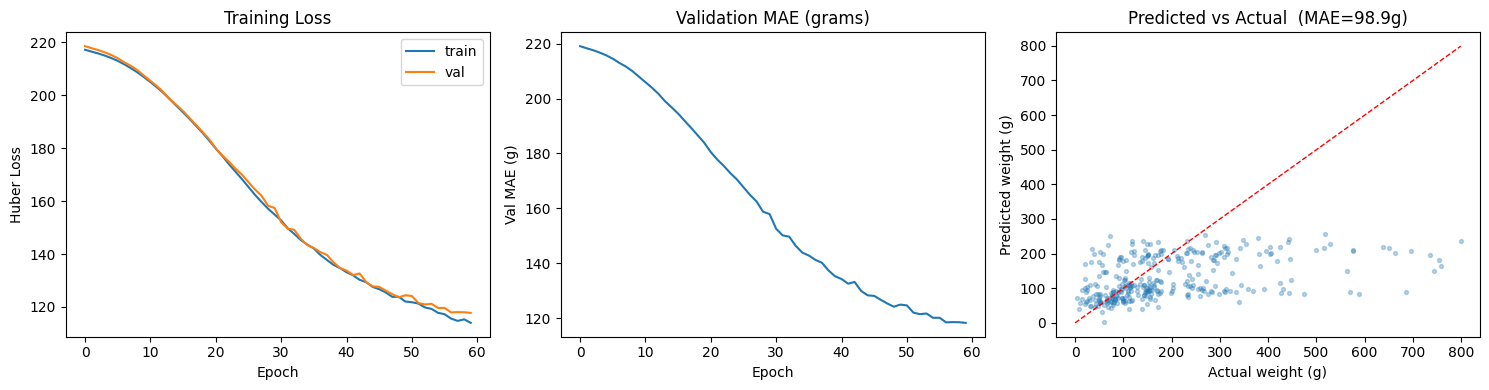

In [ ]:

# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(WEIGHT_MLF_CKPT, map_location=device, weights_only=False)
weight_mlp.load_state_dict(ckpt['model_state_dict'])
weight_mlp.eval()
loaded_constants   = ckpt.get('constants', constants)
_use_log  = ckpt.get('use_log_target', False)
_log_off  = ckpt.get('log_offset', 1.0)
print(f'Loaded epoch {ckpt["epoch"]+1}  |  val_MAE: {ckpt["val_mae_g"]:.1f}g  '
      f'|  log_target={_use_log}')

# ── Test set weight predictions ───────────────────────────────────────────────
all_w_pred_raw = []; all_w_true = []
with torch.no_grad():
    for X_b, y_b in te_loader:
        X_b = X_b.to(device)
        pred = weight_mlp(X_b).cpu().numpy()
        all_w_pred_raw.extend(pred)
        all_w_true.extend(y_b.numpy())   # te_loader holds original grams

all_w_pred_raw = np.array(all_w_pred_raw)
all_w_true     = np.array(all_w_true)

# Invert log transform if used
if _use_log:
    all_w_pred = np.exp(all_w_pred_raw) - _log_off
    all_w_pred = np.maximum(all_w_pred, 10.0)   # clamp to 10g
    print(f'(Inverted log transform: w = exp(raw) − {_log_off})')
else:
    all_w_pred = all_w_pred_raw

weight_mae  = np.abs(all_w_pred - all_w_true).mean()
weight_rmse = np.sqrt(((all_w_pred - all_w_true) ** 2).mean())

print(f'\n── Weight prediction on test set ────────────────────')
print(f'  MAE  : {weight_mae:.1f} g')
print(f'  RMSE : {weight_rmse:.1f} g')
print(f'  Mean actual weight: {all_w_true.mean():.1f} g')
print(f'  Relative error    : {weight_mae/all_w_true.mean()*100:.1f}%')

# ── Derive nutrition estimates using constants ─────────────────────────────────
print(f'\n── Derived nutrition (weight × constant) vs ground truth ──')
const_keys = list(loaded_constants.keys())
for i, col in enumerate(TARGET_COLS):
    key = [k for k in const_keys if col.lower().split('_')[0].replace('total','').strip() in k]
    if not key: key = [const_keys[i]] if i < len(const_keys) else []
    if not key: continue
    c = loaded_constants[key[0]]
    derived      = all_w_pred * c
    ground_truth = nutr_test[:, i]
    mae_nutr     = np.abs(derived - ground_truth).mean()
    print(f'  {col:30s}  MAE={mae_nutr:.1f}  (const={c:.4f}/g)')

# ── Plot: Predicted vs Actual weight ─────────────────────────────────────────
if 'history' in dir():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'],   label='val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss (log scale)')
    axes[0].set_title('Training Loss'); axes[0].legend()

    axes[1].plot(history['val_mae_g'])
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val MAE (g, original scale)')
    axes[1].set_title('Validation MAE (grams)')

    lim = max(all_w_true.max(), all_w_pred.max())
    axes[2].scatter(all_w_true, all_w_pred, alpha=0.3, s=8)
    axes[2].plot([0, lim], [0, lim], 'r--', linewidth=1)
    axes[2].set_xlabel('Actual weight (g)'); axes[2].set_ylabel('Predicted weight (g)')
    axes[2].set_title(f'Predicted vs Actual  (MAE={weight_mae:.1f}g)')

    plt.tight_layout()
    plt.show()


## Cell 8 — Save Artefacts & Download Instructions

Three files need to be downloaded from Kaggle output and placed in `models/`:

In [11]:
# ── All three artefacts are already saved during training ─────────────────────
# Verify they exist
artefacts = [
    (WEIGHT_MLF_CKPT,   'best_weight_mlp.pt       — WeightMLP checkpoint'),
    (NUTR_CONST_PATH,   'nutrition_constants.json  — calorie density constants'),
    (WEIGHT_STATS_PATH, 'weight_feat_stats.npz     — feature normalisation stats'),
]

print('Artefact check:')
all_ok = True
for path, desc in artefacts:
    exists = os.path.isfile(path)
    size   = os.path.getsize(path) if exists else 0
    status = f'✓  {size/1024:.1f} KB' if exists else '✗  MISSING'
    print(f'  {status:15s}  {desc}')
    if not exists: all_ok = False

if all_ok:
    print('\n✓ All artefacts present. Instructions:')
    print('  1. Kaggle → Notebook → Output → Download all')
    print('  2. mv best_weight_mlp.pt nutrition_constants.json weight_feat_stats.npz models/')
    print('  3. python app/app.py    # Phase 6 pipeline loads automatically')
else:
    print('\n⚠ Some artefacts are missing — re-run Cells 3-6.')

# ── Print the constants one more time for the report ─────────────────────────
print('\nNutrition constants (include in project report):')
with open(NUTR_CONST_PATH) as f:
    saved_consts = json.load(f)
for k, v in saved_consts.items():
    print(f'  {k}: {v:.5f}  (i.e. {v:.2f} per gram)')

Artefact check:
  ✓  57.8 KB       best_weight_mlp.pt       — WeightMLP checkpoint
  ✓  0.2 KB        nutrition_constants.json  — calorie density constants
  ✓  0.6 KB        weight_feat_stats.npz     — feature normalisation stats

✓ All artefacts present. Instructions:
  1. Kaggle → Notebook → Output → Download all
  2. mv best_weight_mlp.pt nutrition_constants.json weight_feat_stats.npz models/
  3. python app/app.py    # Phase 6 pipeline loads automatically

Nutrition constants (include in project report):
  calories_per_g: 1.14733  (i.e. 1.15 per gram)
  fat_per_g: 0.05710  (i.e. 0.06 per gram)
  protein_per_g: 0.07498  (i.e. 0.07 per gram)
  carb_per_g: 0.09320  (i.e. 0.09 per gram)


## Cell 9 — Integration: How app.py Uses This

The snippet below shows the Phase 6 inference path in `app/app.py`.  
It is **already implemented** — just download the three artefacts into `models/`.

In [ ]:

"""
Phase 6 inference path in app/app.py  (pseudocode / demo — not executed here)

Step 1 — Predict weight from geometric features
───────────────────────────────────────────────
feat = extract_features(image)          # 9-dim geometric vector
feat_norm = (feat - feat_mean) / feat_std

# MC Dropout: run 30 forward passes with dropout active → mean ± 2σ
raw_samples    = [weight_mlp(feat_norm) for _ in range(30)]
# If log target was used during training, invert: w = exp(raw) - log_offset
if use_log_target:
    weight_samples = [exp(s) - log_offset for s in raw_samples]
else:
    weight_samples = raw_samples
weight_pred_g  = mean(weight_samples)    # e.g. 285.3 g
weight_std_g   = std(weight_samples)     # e.g. 18.2 g

Step 2 — Convert weight to nutrition using dataset constants
────────────────────────────────────────────────────────────
constants = nutrition_constants.json     # cal_per_g, fat_per_g, ...

calories = weight_pred_g × constants['calories_per_g']   # e.g. 1.98 kcal/g
fat      = weight_pred_g × constants['fat_per_g']         # e.g. 0.082 g fat/g
protein  = weight_pred_g × constants['protein_per_g']     # e.g. 0.065 g protein/g
carbs    = weight_pred_g × constants['carbs_per_g']       # e.g. 0.125 g carbs/g

Uncertainty propagates linearly:
  ± calories_uncertainty = weight_std_g × constants['calories_per_g'] × 2
"""

# ── Live demo using the trained model ─────────────────────────────────────────
import torch.nn.functional as F

def predict_weight_and_nutrition(feat_vector: np.ndarray, model: nn.Module,
                                  f_mean, f_std, consts: dict,
                                  use_log_target: bool = False,
                                  log_offset: float = 1.0,
                                  mc_samples: int = 30):
    """
    Full Phase 6 inference:
    feat_vector (9,) → predicted weight (g) → nutrition via constants.
    Returns dict with weight and all macros, including ±2σ uncertainty.

    Parameters
    ----------
    use_log_target : bool
        If True, the model was trained on log(w + log_offset) targets.
        Each raw sample is inverted: w = exp(raw) - log_offset.
    log_offset : float
        The additive offset used during log transform (default 1.0).
    """
    norm_feat = (feat_vector - f_mean.flatten()) / f_std.flatten()
    x = torch.tensor(norm_feat, dtype=torch.float32).unsqueeze(0).to(device)

    # MC Dropout
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout): m.train()
    torch.manual_seed(42)

    raw_samples = []
    with torch.no_grad():
        for _ in range(mc_samples):
            raw_samples.append(model(x).item())
    model.eval()

    # Invert log transform per sample so uncertainty is in gram space
    if use_log_target:
        weight_samples = np.array([np.exp(s) - log_offset for s in raw_samples])
    else:
        weight_samples = np.array(raw_samples)

    weight_samples = np.maximum(weight_samples, 10.0)   # clamp to 10g

    w_mean = weight_samples.mean()
    w_std  = weight_samples.std()

    results = {'weight_g': f'{w_mean:.1f} ± {w_std*2:.1f}g'}
    for key, const in consts.items():
        macro_name = key.replace('_per_g', '')
        mu  = w_mean * const
        sig = w_std  * const * 2
        results[macro_name] = f'{mu:.1f} ± {sig:.1f}'
    return results


# Demo on a random test sample
idx         = random.randint(0, len(X_test_n) - 1)
raw_feat    = X_test[idx]           # un-normalised features for the demo
true_weight = y_test[idx]
true_nutr   = nutr_test[idx]

result = predict_weight_and_nutrition(
    raw_feat, weight_mlp,
    feat_mean, feat_std, loaded_constants,
    use_log_target=_use_log,
    log_offset=_log_off,
)

print('── Phase 6 inference demo ───────────────────────────────')
print(f'True weight : {true_weight:.0f} g')
for i, col in enumerate(TARGET_COLS):
    print(f'True {col:12s}: {true_nutr[i]:.1f}')
print('\nPredictions:')
for k, v in result.items():
    print(f'  {k:20s}: {v}')


── Phase 6 inference demo ───────────────────────────────
True weight : 104 g
True calories    : 218.9
True fat         : 12.6
True protein     : 21.2
True carb        : 3.1

Predictions:
  weight_g            : 119.2 ± 37.3g
  calories            : 136.8 ± 42.8
  fat                 : 6.8 ± 2.1
  protein             : 8.9 ± 2.8
  carb                : 11.1 ± 3.5


## Cell 10 — Summary & Report Notes

### What Phase 6 adds
- **Correct methodology**: predict weight → multiply by constants, matching professor spec §4.3
- **Physical interpretability**: the MLP does pure geometry (area × depth ≈ volume ≈ mass),  
  not nutritional chemistry
- **Uncertainty (MC Dropout)** propagates linearly to each macro:
  $\sigma_{\text{cal}} = \sigma_w \times c_{\text{cal/g}}$

### Key formula for the report
$$\hat{N}_k = \hat{w} \times \bar{c}_k, \quad k \in \{\text{cal, fat, protein, carbs}\}$$

where $\bar{c}_k$ is the robust mean of $N_k^{(i)} / w^{(i)}$ over all Nutrition5K dishes $i$,
and $\hat{w}$ is the WeightMLP prediction.

### Known limitations (acknowledge in report)
- Constants assume **average food density** — a green salad and a piece of cheesecake  
  have very different kcal/g. Phase 5 food classifier (EfficientNet-B0) could supply  
  category-specific constants in a future upgrade.
- MiDaS produces **relative depth** — absolute scale requires camera intrinsics or  
  a reference object. The model compensates through learned scaling in the regression.

### Future: per-category constants
Once Phase 5 and Phase 6 are combined, replace the global constant with a lookup table:
```python
food_type = efficientnet_classifier(image_crop)   # e.g. 'pizza'
cal_const = category_constants[food_type]['cal_per_g']  # e.g. 2.8 kcal/g for pizza
calories  = predicted_weight * cal_const
```